## Prepare

In [53]:
import os
import pathlib
from functools import partial

import folium
import mcr_py.helper_functions
import mcr_py.mcr5.labels
import mcr_py.minute_city.minute_city
import polars as pl
import scienceplots  # noqa: F401
import seaborn as sns
from matplotlib import pyplot as plt
from mcr_py.utils import strtime
from mcr_py.utils.h3 import (
    plot_h3_cells_discrete_colors_on_folium,
    plot_h3_cells_on_folium,
)
from mcr_py.utils.logger import setup

setup("INFO")

In [34]:
city_name = "cologne"
date = "20250718"

In [56]:
data_directory = pathlib.Path("../data/")
base_directory = data_directory / date
cache_path = base_directory / "cache/"
osm_path = base_directory / "osm_raw"
geometa_path = base_directory / f"cache/{city_name}_geometa.pkl"
mcr5_output_path = base_directory / f"mcr5_results/{city_name}"
profiles_tariffs_path = mcr5_output_path / "profiles_tariffs.parquet"
profiles_categories_path = mcr5_output_path / "profiles_categories_tariffs.parquet"

geo_meta, geo_data = mcr_py.helper_functions.load_auxiliary_classes(
    geo_meta_path=geometa_path,
    city_id="Koeln",
    osm_path=osm_path,
    cache_path=cache_path,
)

[11:00:41] INFO     Loading OSM walking                               ]8;id=528106;file:///home/ppeter/repo/mcr-py/python/mcr_py/mcr/data.py\data.py]8;;\:]8;id=773272;file:///home/ppeter/repo/mcr-py/python/mcr_py/mcr/data.py#62\62]8;;\
[11:00:44] INFO     Loading OSM walking done (2.51 seconds)           ]8;id=596718;file:///home/ppeter/repo/mcr-py/python/mcr_py/mcr/data.py\data.py]8;;\:]8;id=497366;file:///home/ppeter/repo/mcr-py/python/mcr_py/mcr/data.py#62\62]8;;\
           INFO     Loading OSM POIs                                  ]8;id=982300;file:///home/ppeter/repo/mcr-py/python/mcr_py/mcr/data.py\data.py]8;;\:]8;id=616267;file:///home/ppeter/repo/mcr-py/python/mcr_py/mcr/data.py#69\69]8;;\
           INFO     Loading OSM POIs done (0.02 seconds)              ]8;id=108242;file:///home/ppeter/repo/mcr-py/python/mcr_py/mcr/data.py\data.py]8;;\:]8;id=767471;file:///home/ppeter/repo/mcr-py/python/mcr_py/mcr/data.py#69\69]8;;\
           INFO     Load

## Other substitional data

In [36]:
# zones = gpd.read_file(
#     "../data/zones.csv", GEOM_POSSIBLE_NAMES="geometry", KEEP_GEOM_COLUMNS="NO"
# )
# zones["valid_from"] = pd.to_datetime(zones["valid_from"])
# zones["valid_till"] = pd.to_datetime(zones["valid_till"])

# color_map = {
#     "chargeable_return": "red",
#     "free_return": "green",
# }


# def plot_zones(m: folium.Map, zones: gpd.GeoDataFrame, time: datetime):
#     zones = zones[(zones["valid_from"] <= time) & (zones["valid_till"] >= time)]
#     # zones = zones[zones["category"] == "free_return"]
#     zones = zones.sort_values("category")
#     print(f"plotting {len(zones)} zones")
#     for _, zone in zones.iterrows():
#         print(color_map[zone["category"]])
#         folium.GeoJson(
#             zone.geometry,
#             name=zone["name"],
#             style_function=lambda x: {
#                 "color": "black",
#                 "fillOpacity": 0.5,
#                 "fillColor": color_map[zone["category"]],
#             },
#         ).add_to(m)

In [37]:
# from package import storage

# bicycle_location_paths = [
#     entry.path for entry in os.scandir("../data/bicycle_locations") if entry.is_file()
# ]

# bicycle_locations_dict = {}

# for bicycle_location_path in bicycle_location_paths:
#     bicycle_locations = storage.read_df(bicycle_location_path)
#     bicycle_locations = gpd.GeoDataFrame(
#         bicycle_locations,
#         geometry=gpd.points_from_xy(
#             bicycle_locations.lon,
#             bicycle_locations.lat,
#         ),
#     )
#     bicycle_locations_dict[bicycle_location_path] = bicycle_locations

# all_bicycle_locations = pd.concat(bicycle_locations_dict.values())


# def plot_bicycle_locations(
#     m: folium.Map,
#     bicycle_locations: gpd.GeoDataFrame,
#     as_heatmap: bool = False,
#     color="orange",
# ):
#     if as_heatmap:
#         HeatMap(
#             data=bicycle_locations[["lat", "lon"]].to_numpy().tolist(),
#             radius=5,
#             blur=5,
#         ).add_to(m)
#     else:
#         for _, bicycle_location in bicycle_locations.iterrows():
#             folium.CircleMarker(
#                 location=(bicycle_location.geometry.y, bicycle_location.geometry.x),
#                 popup="bicycle",
#                 radius=6,
#                 weight=1,
#                 color="black",
#                 fill=True,
#                 fillColor=color,
#                 opacity=1,
#                 fillOpacity=1,
#             ).add_to(m)

In [38]:
# stops = storage.read_gdf("../data/cleaned/stops.csv")


# def plot_stops(m: folium.Map, stops: gpd.GeoDataFrame, color="yellow"):
#     for _, stop in stops.iterrows():
#         folium.CircleMarker(
#             location=(stop.geometry.y, stop.geometry.x),
#             popup="stop",
#             radius=6,
#             weight=1,
#             color="black",
#             fill=True,
#             fillColor=color,
#             fillOpacity=1,
#             opacity=1,
#         ).add_to(m)

## Results

In [39]:
profiles_df_tariffs = pl.read_parquet(profiles_tariffs_path)
profiles_df_categories_tariffs = pl.read_parquet(profiles_categories_path)

In [40]:
scenario_labels = {
    "bicycle_public_transport": "Combined",
    "bicycle": "Bicycle",
    "public_transport": "Public Transport",
    "walking": "Walking",
    "car": "Car",
}

profiles_df_tariffs = profiles_df_tariffs.with_columns(
    pl.col("scenario").replace_strict(scenario_labels),
    pl.col("core_scenario").replace_strict(scenario_labels),
)

profiles_df_categories_tariffs = profiles_df_categories_tariffs.with_columns(
    pl.col("scenario").replace_strict(scenario_labels),
    pl.col("core_scenario").replace_strict(scenario_labels),
)

In [41]:
core_scenarios_to_check = ["Bicycle", "Combined", "Public Transport", "Walking"]

# Filter rows where core_scenario is in the list of core scenarios to check
filtered_df = profiles_df_tariffs.filter(
    pl.col("core_scenario").is_in(core_scenarios_to_check)
)

# Create a boolean mask to identify rows where cost_0 is not equal for the same hex_id and category
mask = filtered_df.group_by("hex_id").agg(pl.col("cost_0").n_unique() == 1)
# If this would be true for any row, the computation before was wrong
mask.filter(~pl.col("cost_0"))

hex_id,cost_0
str,bool


In [42]:
profiles_df_tariffs_unaggregated = profiles_df_tariffs

In [43]:
profiles_df_tariffs = (
    profiles_df_tariffs.drop(["scenario"])
    .group_by(["core_scenario", "hex_id"])
    .mean()
    .with_columns(pl.col("core_scenario").alias("scenario"))
)

In [44]:
uncertain_scenarios = ["Public Transport", "Bicycle", "Combined"]

profiles_std_df = (
    profiles_df_tariffs_unaggregated.drop(["scenario"])
    .filter(pl.col("core_scenario").is_in(uncertain_scenarios))
    .group_by(["core_scenario", "hex_id"])
    .agg(pl.all().std())
    .with_columns(pl.col("core_scenario").alias("scenario"))
)

In [45]:
best = profiles_df_tariffs_unaggregated.select(
    pl.all()
    .top_k_by("optimal", k=1)
    .over(["core_scenario", "hex_id"], mapping_strategy="explode")
)
worst = profiles_df_tariffs_unaggregated.select(
    pl.all()
    .bottom_k_by("optimal", k=1)
    .over(["core_scenario", "hex_id"], mapping_strategy="explode")
)

In [14]:
# best = (
#     profiles_df_unaggregated_reset.drop(columns=["scenario"])
#     .groupby(["core_scenario", "hex_id"])["optimal"]
#     .idxmin()
# )
# worst = (
#     profiles_df_unaggregated_reset.drop(columns=["scenario"])
#     .groupby(["core_scenario", "hex_id"])["optimal"]
#     .idxmax()
# )

# Results

### Required cost tables

Profiles mean

In [46]:
required_cost_description = profiles_df_tariffs.group_by("scenario").agg(
    pl.col("required_cost_for_optimal_in_euro").mean().alias("mean"),
    pl.col("required_cost_for_optimal_in_euro").quantile(0.25).alias("25%"),
    pl.col("required_cost_for_optimal_in_euro").quantile(0.5).alias("50%"),
    pl.col("required_cost_for_optimal_in_euro").quantile(0.75).alias("75%"),
    pl.col("required_cost_for_optimal_in_euro").max().alias("max"),
)
# required_cost_description_style = required_cost_description.style.format(precision=2)
# print(required_cost_description_style.to_latex())
required_cost_description

scenario,mean,25%,50%,75%,max
str,f64,f64,f64,f64,f64
"""Walking""",0.0,0.0,0.0,0.0,0.0


Profiles best case

In [ ]:
required_cost_description = profiles_best_case_df.groupby("core_scenario")[
    "required_cost_for_optimal_in_euro"
].describe()
required_cost_description = required_cost_description[["mean", "25%", "50%", "75%", "max"]]
# required_cost_description_style = required_cost_description.style.format(precision=2)
# print(required_cost_description_style.to_latex())
required_cost_description

Profiles worst case

In [ ]:
required_cost_description = profiles_worst_case_df.groupby("core_scenario")[
    "required_cost_for_optimal_in_euro"
].describe()
required_cost_description = required_cost_description[["mean", "25%", "50%", "75%", "max"]]
required_cost_description_style = required_cost_description.style.format(precision=2)
# print(required_cost_description_style.to_latex())
required_cost_description

### Optimal tables

Profiles mean

In [ ]:
from datetime import timedelta


def timedelta_formatter(x) -> str:
    td = timedelta(minutes=x)
    minutes = td.seconds // 60
    seconds = td.seconds % 60
    return f"{minutes}m {seconds:02d}s"


# timedelta_formatter = lambda x: timedelta(minutes=x)

In [47]:
optimal_description = profiles_df_tariffs.group_by("scenario").agg(
    pl.col("optimal_in_minutes").mean().alias("mean"),
    pl.col("optimal_in_minutes").quantile(0.25).alias("25%"),
    pl.col("optimal_in_minutes").quantile(0.5).alias("50%"),
    pl.col("optimal_in_minutes").quantile(0.75).alias("75%"),
    pl.col("optimal_in_minutes").max().alias("max"),
)
optimal_description = optimal_description.select(
    ["scenario", "mean", "25%", "50%", "75%", "max"]
)
# optimal_description_style = optimal_description.style.format(timedelta_formatter)
# print(optimal_description_style.to_latex())
optimal_description

scenario,mean,25%,50%,75%,max
str,f64,f64,f64,f64,f64
"""Walking""",24.411052,14.133333,22.933333,33.766667,71.283333


In [ ]:
optimal_std_description = profiles_std_df.groupby("scenario")["optimal_in_minutes"].describe()
optimal_std_description = optimal_std_description[["mean", "min", "25%", "50%", "75%", "max"]]
optimal_std_description_style = optimal_std_description.style.format(timedelta_formatter)
optimal_std_description["CV"] = (
    optimal_std_description["mean"]
    / optimal_description.drop(index=["Car", "Walking"])["mean"]
)
# print(optimal_std_description_style.to_latex())
optimal_std_description

Profiles best case

In [ ]:
optimal_description_best = profiles_best_case_df.groupby("core_scenario")[
    "optimal_in_minutes"
].describe()
optimal_description_best = optimal_description_best[["mean", "25%", "50%", "75%"]]
optimal_description_style = optimal_description_best.style.format(timedelta_formatter)
# print(optimal_description_style.to_latex())
optimal_description_best

Profiles worst case

In [ ]:
optimal_description_worst = profiles_worst_case_df.groupby("core_scenario")[
    "optimal_in_minutes"
].describe()
optimal_description_worst = optimal_description_worst[["mean", "25%", "50%", "75%"]]
optimal_description_style = optimal_description_worst.style.format(timedelta_formatter)
# print(optimal_description_style.to_latex())
optimal_description_worst

best vs worst case

In [ ]:
optimal_diff = optimal_description_worst - optimal_description_best
optimal_diff_style = optimal_diff.style.format(timedelta_formatter)
# print(optimal_diff_style.to_latex())
optimal_diff

### Differences in optimals

In [ ]:
def format_minutes_diff(diff: float) -> str:
    minutes = int(diff)
    seconds = int((diff - minutes) * 60)
    return f"{minutes:02d}m {seconds:02d}s"

In [ ]:
print(
    format_minutes_diff(
        optimal_description.loc["Walking", "mean"]
        - optimal_description.loc["Public Transport", "mean"]
    )
)

In [ ]:
print(
    format_minutes_diff(
        optimal_description.loc["Walking", "mean"] - optimal_description.loc["Bicycle", "mean"]
    )
)

In [ ]:
print(
    format_minutes_diff(
        optimal_description.loc["Bicycle", "mean"]
        - optimal_description.loc["Combined", "mean"]
    )
)

In [ ]:
print(
    format_minutes_diff(
        optimal_description.loc["Public Transport", "mean"]
        - optimal_description.loc["Combined", "mean"]
    )
)

### Plotting distributions

In [57]:
hex_test_comp = mcr_py.mcr5.labels.read_labels_for_nodes(
    str(pathlib.Path("../data/mcr5/cologne_20240423") / "walking"),
    geo_data.pois.with_columns(pl.col("nearest_osm_node").alias("osm_node_id")).lazy(),
)
hex_test_comp = mcr_py.minute_city.minute_city.add_pois_to_labels(
    hex_test_comp.lazy(), geo_data.pois.lazy()
)
hex_test_comp = hex_test_comp.collect()

In [48]:
plt.style.use(["science", "grid", "ieee"])
plt.rcParams.update({"font.size": 20})


def plot_sorted_grouped_data(
    df: pl.DataFrame, group_column: str, value_column: str, ax, color_map=None
) -> None:
    df = df.sort(value_column)

    group_sizes = df.get_column(group_column).unique().len()
    group_size = df.filter(
        pl.col(group_column) == df.get_column(group_column).unique()[0]
    ).shape[0]

    colors = plt.cm.tab10.colors[:group_sizes]

    for color, group_value in zip(
        colors, df.get_column(group_column).unique().to_list(), strict=False
    ):
        group_data = df.filter(pl.col(group_column) == group_value)
        if group_value in color_map:
            color = color_map[group_value]
        ax.plot(
            range(group_size),
            group_data.get_column(value_column),
            color=color,
            linewidth=2,
            label=group_value,
        )

    ax.legend()
    ax.set_xlim(0, group_size)
    ax.set_xticks(
        [0, 0.25 * group_size, 0.5 * group_size, 0.75 * group_size, group_size],
        ["0", "25%", "50%", "75%", "100%"],
    )

In [49]:
import pathlib

image_path = f"../figures/mcr5/{city_name}_{date}"
pathlib.Path(image_path).mkdir(parents=True, exist_ok=True)

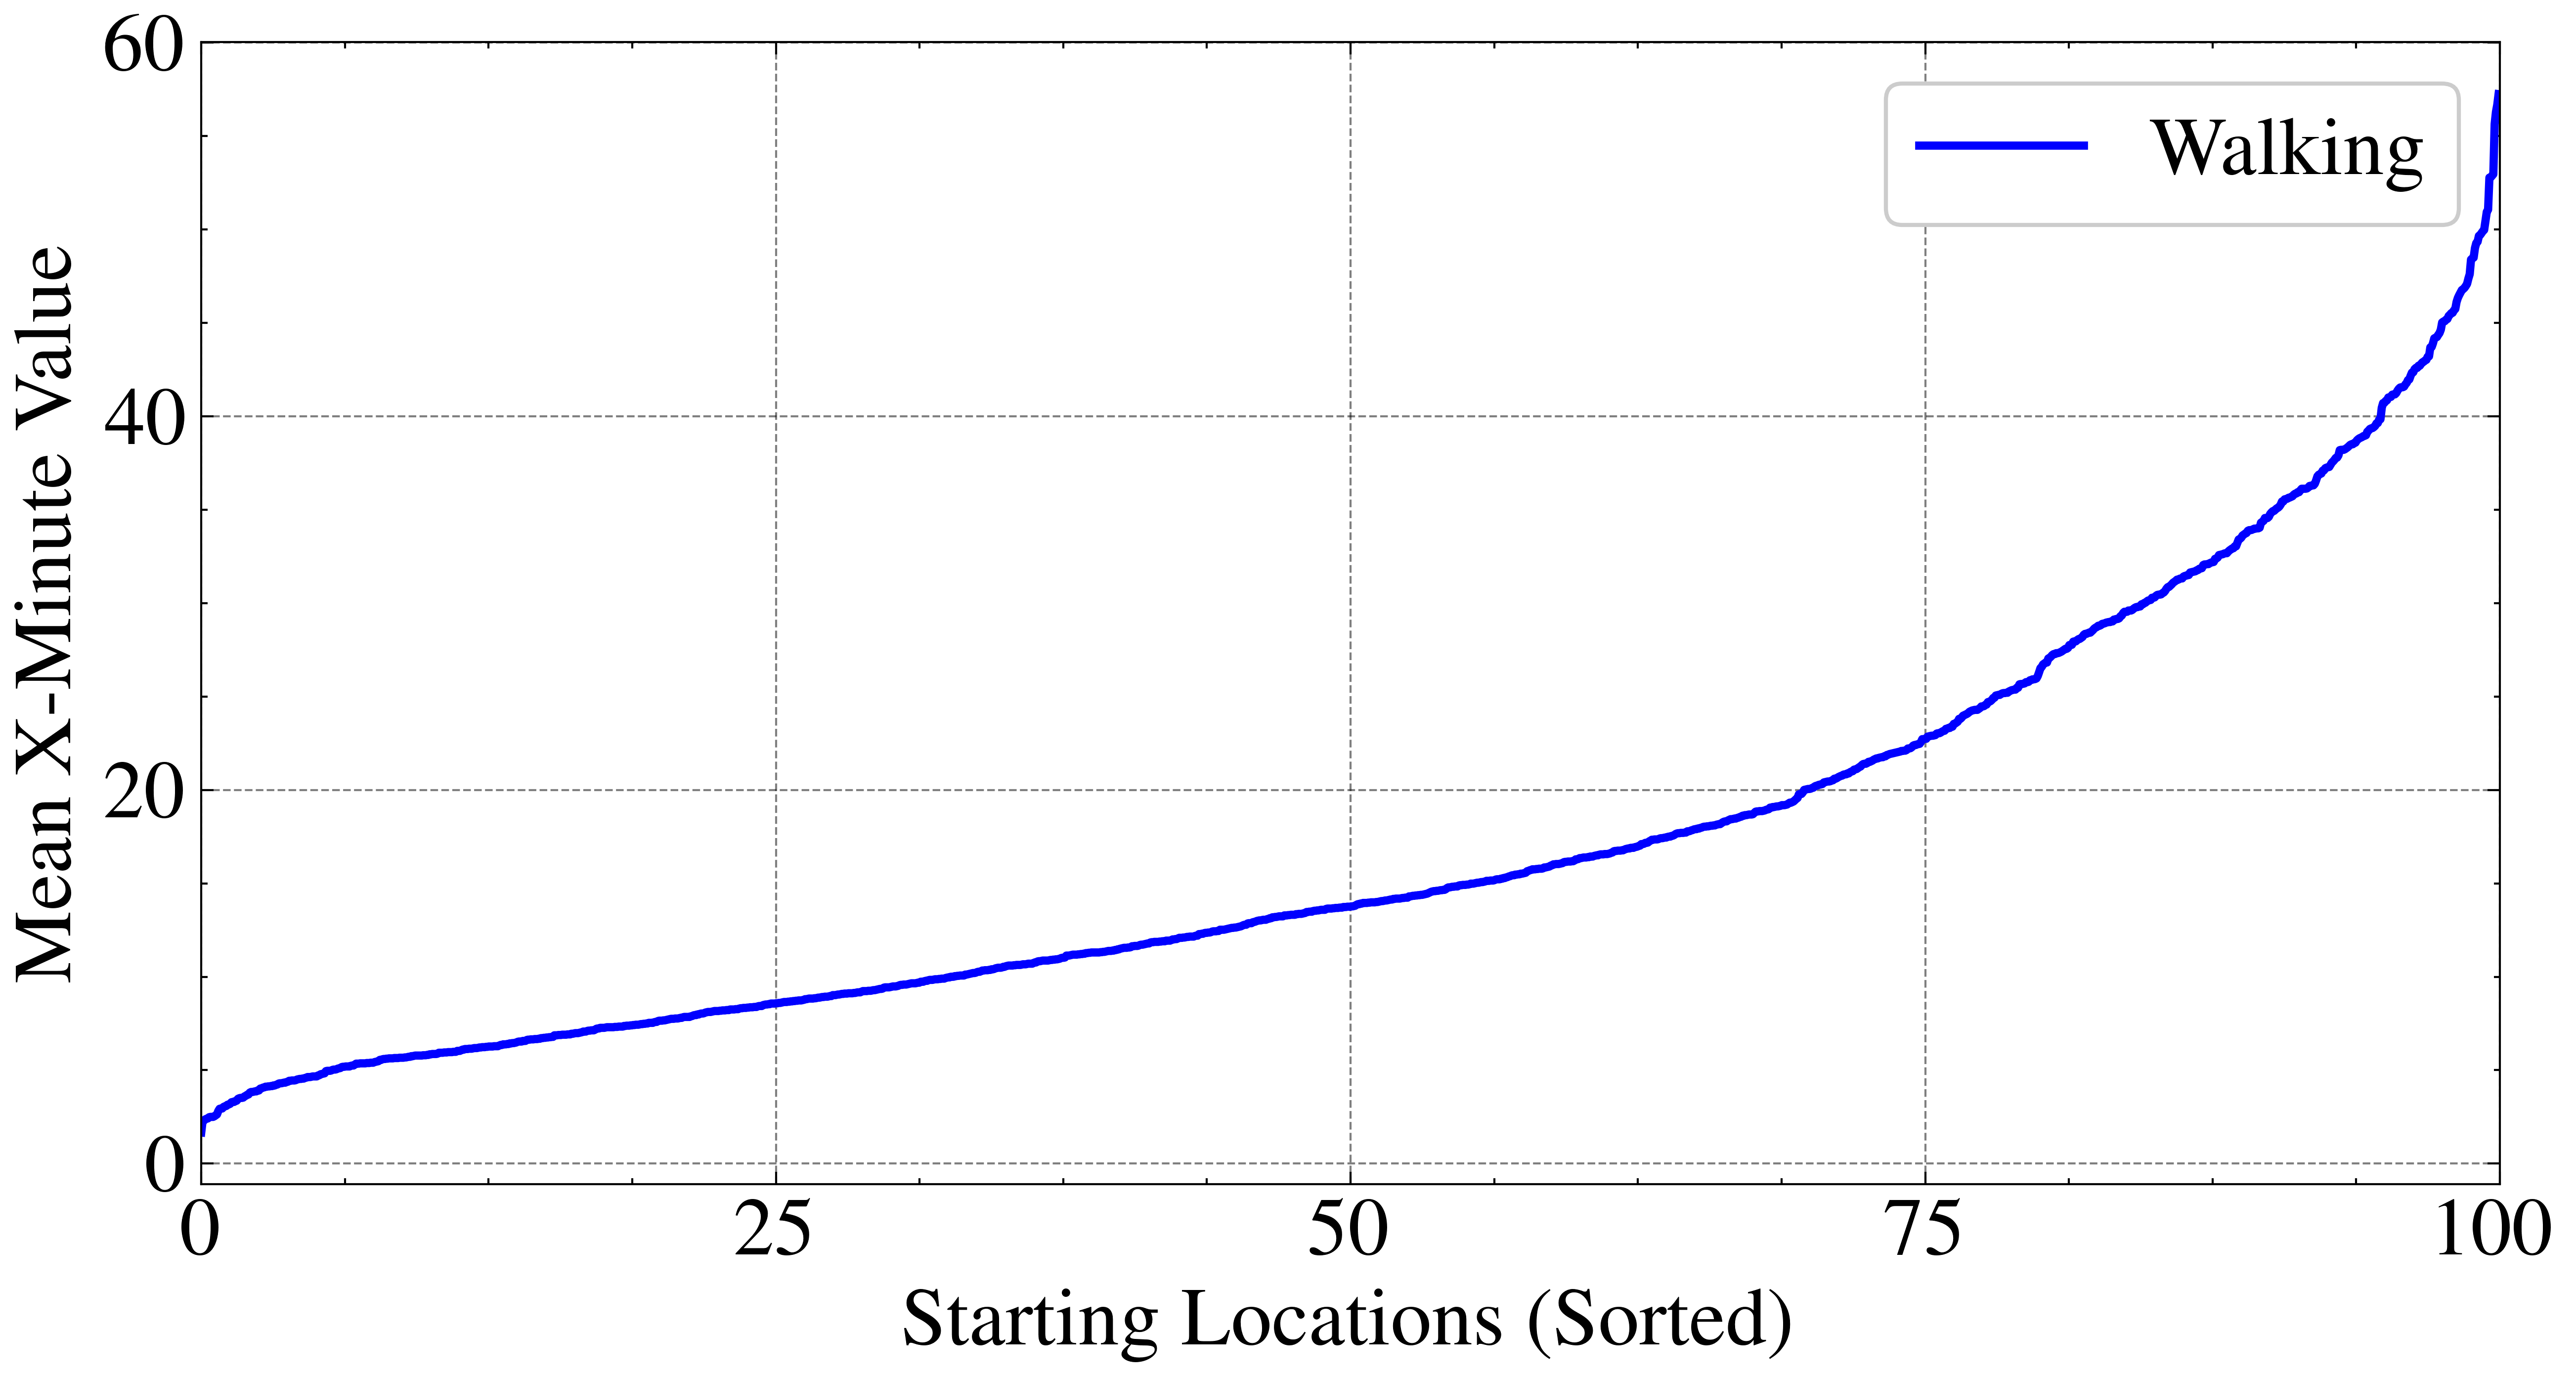

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_sorted_grouped_data(
    profiles_df_tariffs.filter(pl.col("scenario") != "Car").filter(
        pl.col("hex_id").is_in(hex_test_comp.get_column("start_id_hex").unique().to_list())
    ),
    "scenario",
    "optimal_in_minutes",
    ax,
    color_map={
        "Walking": "blue",
        "Bicycle": "yellow",
        "Public Transport": "red",
        "Combined": "orange",
    },
)
# ax.set_title("Best X-Minute-City for each Hexagon")
ax.set_ylabel("Mean X-Minute Value")
ax.set_xlabel("Starting Locations (Sorted)")

plt.savefig(f"{image_path}/best_x_minute_city.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_sorted_grouped_data(
    profiles_df_tariffs[profiles_df_tariffs.scenario != "Car"],
    "scenario",
    "required_cost_for_optimal_in_euro",
    ax,
    color_map={
        "Walking": "blue",
        "Bicycle": "yellow",
        "Public Transport": "red",
        "Combined": "orange",
    },
)
ax.set_title("Maximum Required Cost for X-Minute-City for each Hexagon")
ax.set_ylabel("Maximum Required Cost for X-Minute-City (€))")
ax.set_xlabel("Hexagons (sorted)")

plt.savefig(
    f"{image_path}/maximum_required_cost_for_x_minute_city.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Differences in subscenarios

In [ ]:
import matplotlib.pyplot as plt


def plot_difference_in_subscenario(scenario_df, scenario_title, ax) -> None:
    if not ax:
        fig, ax = plt.subplots(figsize=(10, 5))
    scenario_df.groupby("hex_id")["optimal_in_minutes"].min().sort_values().plot(ax=ax)
    scenario_df.groupby("hex_id")["optimal_in_minutes"].max().sort_values().plot(ax=ax)
    print(
        scenario_df.groupby("hex_id")["optimal_in_minutes"].max().mean()
        - scenario_df.groupby("hex_id")["optimal_in_minutes"].min().mean()
    )

    ax.set_title(scenario_title)
    ax.set_ylabel("Time (Minutes)")
    ax.set_xlabel("Hexagons (Sorted)")

    ax.set_xlim(
        0, len(scenario_df.groupby("hex_id")["optimal_in_minutes"].min().sort_values())
    )
    ax.axhline(15, color="red", linestyle="--")
    ax.set_xticks([])

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

public_transport_profiles_df = profiles_df_tariffs_unaggregated[
    profiles_df_tariffs_unaggregated["core_scenario"] == "Public Transport"
]
plot_difference_in_subscenario(public_transport_profiles_df, "Public Transport", axes[0])

bicycle_profiles_df = profiles_df_tariffs_unaggregated[
    profiles_df_tariffs_unaggregated["core_scenario"] == "Bicycle"
]
plot_difference_in_subscenario(bicycle_profiles_df, "Bicycle", axes[1])

bicycle_pt_profiles_df = profiles_df_tariffs_unaggregated[
    profiles_df_tariffs_unaggregated["core_scenario"] == "Combined"
]
plot_difference_in_subscenario(bicycle_pt_profiles_df, "Combined", axes[2])

fig.suptitle("Best And Worst Case of Optimal Time for each Hexagon")

plt.savefig(
    f"{image_path}/optimal_best_worst_case.png",
    dpi=300,
    bbox_inches="tight",
)

### Value-Cost profiles for each scenario

In [ ]:
cost_columns = [col for col in profiles_df.columns if col.startswith("cost_")]
cost_columns_tariffs = [col for col in profiles_df_tariffs.columns if col.startswith("cost_")]

In [ ]:
import numpy as np

no_inf_profiles_df = profiles_df_tariffs[
    np.isinf(profiles_df_tariffs[cost_columns_tariffs]).sum(axis=1) == 0
]

In [ ]:
def get_aggregated_cost_per_scenario(profiles_df, cost_columns, aggregation_metric):
    aggregated_per_cost_per_scenario = profiles_df.groupby("scenario")[cost_columns].agg(
        aggregation_metric
    )
    aggregated_per_cost_per_scenario.columns = [
        int(column.split("_")[1]) for column in aggregated_per_cost_per_scenario.columns
    ]
    aggregated_per_cost_per_scenario = aggregated_per_cost_per_scenario.T

    maximum_time = aggregated_per_cost_per_scenario.max(numeric_only=True).max()

    aggregated_per_cost_per_scenario = aggregated_per_cost_per_scenario / 60
    aggregated_per_cost_per_scenario.index = aggregated_per_cost_per_scenario.index / 100

    return aggregated_per_cost_per_scenario, maximum_time

In [ ]:
no_inf_profiles_df.groupby("scenario")[cost_columns].mean()

In [ ]:
mean_per_cost_per_scenario, maximum_time = get_aggregated_cost_per_scenario(
    no_inf_profiles_df, cost_columns, "mean"
)

In [ ]:
plt.rcParams.update({"font.size": 8})
example_hex = (
    no_inf_profiles_df.loc["891fa18b083ffff"][cost_columns + ["scenario"]]
    .rename(columns=lambda x: int(x.split("_")[1]) if x.startswith("cost_") else x)
    .set_index("scenario")
    .T
    / 60
)
example_hex.index = example_hex.index.astype(int) / 100
example_hex = example_hex.drop(columns=["Car"])

ax = sns.lineplot(example_hex, drawstyle="steps-post")
ax.set_xlim(0, example_hex.index.max())
ax.set_title("Example Hexagon")
ax.set_ylabel("Time (Minutes)")
ax.set_xlabel("Cost (€)")

plt.savefig(f"{image_path}/example_profile.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
def calculate_diffs(profile):
    costs = list(profile.index)
    prev_best_cost = 0
    diffs = []

    for cost, time in profile.items():
        prev_cost_index = costs.index(cost) - 1
        if prev_cost_index < 0:
            continue
        prev_cost = costs[prev_cost_index]
        prev_time = profile[prev_cost]

        if prev_time > time:
            euro_per_minute = (cost - prev_best_cost) / (prev_time - time)
            minute_per_euro = (prev_time - time) / (cost - prev_best_cost)

            diffs.append(
                {
                    "improvement": prev_time - time,
                    "at_cost": cost,
                    "for_time": time,
                    "cost_diff": cost - prev_best_cost,
                    "minute_per_euro": minute_per_euro,
                    "euro_per_minute": euro_per_minute,
                }
            )

            prev_best_cost = cost
    diffs_df = pd.DataFrame(diffs)
    return diffs_df

In [ ]:
def pretty_print_latex(df, precision=2) -> None:
    df = df.copy()
    df.columns = [col.replace("_", " ") for col in df.columns]

    def replace_underscore(cell):
        # Replace underscores with spaces if the cell is a string
        if isinstance(cell, str):
            return cell.replace("_", " ")
        return cell

    df = df.applymap(replace_underscore)
    df.style.format(precision=precision).format_index("")

    print(style.to_latex())

In [ ]:
def calculate_all_diffs(profiles_df):
    diffs_dfs = []
    for col in profiles_df.columns:
        diffs_df = calculate_diffs(profiles_df[col])
        diffs_df["scenario"] = col
        diffs_dfs.append(diffs_df)
    return pd.concat(diffs_dfs)

In [ ]:
diffs_df = calculate_all_diffs(example_hex)
pretty_print_latex(diffs_df[["improvement", "at_cost", "minute_per_euro", "scenario"]])
diffs_df

In [ ]:
ax = sns.lineplot(
    data=mean_per_cost_per_scenario[
        [scenario for scenario in mean_per_cost_per_scenario.columns if scenario != "Car"]
    ],
    drawstyle="steps-post",
)
ax.set_xlim(0, mean_per_cost_per_scenario.index.max())
# ax.set_ylim(0,maximum_time+100)
ax.set_title("Mean Time per Cost for each Scenario")
ax.set_ylabel("Mean Time (Minutes)")
ax.set_xlabel("Cost (€)")

plt.savefig(
    f"{image_path}/mean_time_per_cost_for_each_scenario.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Zeitgewinn pro Kosten leich ablesbar

In [ ]:
ax = sns.lineplot(data=mean_per_cost_per_scenario.drop(columns="Car"), drawstyle="steps-post")
ax.set_xlim(0, mean_per_cost_per_scenario.index.max())
ax.set_title("Mean Time per Cost for each Scenario")
ax.set_ylabel("Mean Time (Minutes)")
ax.set_xlabel("Cost (€)")


plt.savefig(
    f"{image_path}/mean_time_per_cost_for_each_scenario_without_car.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
diffs_df = calculate_all_diffs(mean_per_cost_per_scenario.drop(columns=["Car", "Combined"]))
pretty_print_latex(
    diffs_df[
        ["improvement", "at_cost", "cost_diff", "minute_per_euro", "scenario"]
    ].sort_values("improvement", ascending=False),
    precision=3,
)
diffs_df

In [ ]:
quantile_25_per_cost_per_scenario, maximum_time = get_aggregated_cost_per_scenario(
    no_inf_profiles_df, cost_columns, lambda x: x.quantile(0.25)
)
ax = sns.lineplot(
    data=quantile_25_per_cost_per_scenario.drop(columns="Car"), drawstyle="steps-post"
)
ax.set_xlim(0, mean_per_cost_per_scenario.index.max())
ax.set_title("25% Quantile Time per Cost for each Scenario")
ax.set_ylabel("Mean Time (Minutes)")
ax.set_xlabel("Cost (€)")


plt.savefig(
    f"{image_path}/quantile_25_time_per_cost_for_each_scenario_without_car.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
diffs_df = calculate_all_diffs(
    quantile_25_per_cost_per_scenario.drop(columns=["Car", "Combined"])
)
pretty_print_latex(
    diffs_df[
        ["improvement", "at_cost", "cost_diff", "minute_per_euro", "scenario"]
    ].sort_values("improvement", ascending=False),
    precision=3,
)
diffs_df

In [ ]:
profiles_df_tariffs[profiles_df_tariffs.scenario == "Combined"][
    "required_cost_for_optimal_in_euro"
].describe()

-> fahhrad nützlich

In [ ]:
quantile_75_per_cost_per_scenario, maximum_time = get_aggregated_cost_per_scenario(
    no_inf_profiles_df, cost_columns, lambda x: x.quantile(0.75)
)
ax = sns.lineplot(
    data=quantile_75_per_cost_per_scenario.drop(columns="Car"), drawstyle="steps-post"
)
ax.set_xlim(0, mean_per_cost_per_scenario.index.max())
ax.set_title("Mean Time per Cost for each Scenario")
ax.set_ylabel("Mean Time (Minutes)")
ax.set_xlabel("Cost (€)")


plt.savefig(
    f"{image_path}/quantile_75_time_per_cost_for_each_scenario_without_car.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
diffs_df = calculate_all_diffs(
    quantile_75_per_cost_per_scenario.drop(columns=["Car", "Combined"])
)[["improvement", "at_cost", "cost_diff", "minute_per_euro", "scenario"]].sort_values(
    "improvement", ascending=False
)
pretty_print_latex(
    diffs_df,
    precision=3,
)
diffs_df

In [ ]:
quantile_90_per_cost_per_scenario, maximum_time = get_aggregated_cost_per_scenario(
    no_inf_profiles_df, cost_columns, lambda x: x.quantile(0.90)
)
ax = sns.lineplot(
    data=quantile_90_per_cost_per_scenario.drop(columns="Car"), drawstyle="steps-post"
)
ax.set_xlim(0, mean_per_cost_per_scenario.index.max())
ax.set_title("Mean Time per Cost for each Scenario")
ax.set_ylabel("Mean Time (Minutes)")
ax.set_xlabel("Cost (€)")


plt.savefig(
    f"{image_path}/quantile_90_time_per_cost_for_each_scenario_without_car.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
diffs_df = calculate_all_diffs(
    quantile_90_per_cost_per_scenario.drop(columns=["Car", "Combined"])
)[["improvement", "at_cost", "cost_diff", "minute_per_euro", "scenario"]].sort_values(
    "improvement", ascending=False
)
pretty_print_latex(
    diffs_df,
    precision=3,
)
diffs_df

In [ ]:
discretize_time = partial(
    pd.cut,
    bins=[0, 60 * 10, 60 * 15, 60 * 20, np.inf],
    labels=[
        "Under 10 Minutes",
        "Under 15 Minutes",
        "Under 20 Minutes",
        "Over 20 Minutes",
    ],
)

discrete_walking = discretize_time(
    profiles_df_tariffs[profiles_df_tariffs.scenario == "Walking"]
    .groupby(level=0)["optimal"]
    .mean()
)
discrete_pt_bike = discretize_time(
    profiles_df_tariffs[profiles_df_tariffs.scenario == "Combined"]
    .groupby(level=0)["optimal"]
    .mean()
)

In [ ]:
profiles_df_tariffs[profiles_df_tariffs.scenario != "Car"].groupby(level=0)[
    "required_cost_for_optimal_in_euro"
].mean().max()

In [ ]:
hex_cost = (
    profiles_df_tariffs[profiles_df_tariffs.scenario == "Combined"]
    .groupby(level=0)["required_cost_for_optimal_in_euro"]
    .mean()
)
discrete_hex_costs = pd.cut(
    hex_cost,
    [-1, 0.01, 0.5, 1, 1.5, 2],
    labels=[
        "0 Euro",
        "0,50 Euro",
        "1 Euro",
        "1,50 Euro",
        "2 Euro",
    ],
)

In [ ]:
from PIL import Image


def convert_map_png(folium_map, file_name):
    htmlfile = f"../tmp/figures/{file_name}.html"
    pdffile = f"../tmp/figures/{file_name}.pdf"
    pngfile = f"../figures/mcr5/{city}_{date}/{file_name}.png"

    # Get HTML File of Map
    folium_map.save(htmlfile)

    # Convert Map from HTML to PDF, Delay to Allow Rendering
    options = {
        "javascript-delay": 500,
        "page-size": "Letter",
        "margin-top": "0.0in",
        "margin-right": "0.0in",
        "margin-bottom": "0.0in",
        "margin-left": "0.0in",
        "encoding": "UTF-8",
        "custom-header": [("Accept-Encoding", "gzip")],
    }
    pdfkit.from_file(htmlfile, (pdffile), options=options)

    # Convert Map from PDF to PNG
    doc = fitz.open(pdffile)
    page = doc.load_page(0)
    pix = page.get_pixmap()
    pix.save(pngfile)
    doc.close()

    # Crop Out Map Image
    pilImage = Image.open(pngfile)

    # croppedImage = pilImage.crop(
    #     (20, 100, 550, 740)
    # )  # Adjust this if your map renders differently on PDF
    # croppedImage.save(pngfile)

    return pilImage

In [ ]:
discrete_walking.value_counts() / discrete_walking.shape[0]

In [ ]:
discrete_pt_bike.value_counts() / discrete_pt_bike.shape[0]

In [ ]:
temp = (
    profiles_df_tariffs[profiles_df_tariffs.scenario == "Walking"]
    .groupby(level=0)["optimal"]
    .mean()
)
temp[temp > 20 * 60].median() / 60

In [ ]:
import seaborn as sns

palette = sns.color_palette("muted")
palette

### Plotting optimal on map

In [ ]:
create_map = partial(
    folium.Map,
    location=geo_meta.get_center_lat_lon(),
    tiles="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
    attr="Carto",
    zoom_start=12,
    height=1500,
    width=1000,
)

m = create_map()


def seconds_to_minutes(seconds):
    return seconds / 60


map_legend_opts = {
    "show_legend": True,
    # "legend_value_callback": seconds_to_minutes,
    "legend_caption": "Minutes",
}

plot_h3_discrete_map = partial(
    plot_h3_cells_discrete_colors_on_folium,
    color_scheme={
        "Under 10 Minutes": "green",
        "Under 15 Minutes": "yellow",
        "Under 20 Minutes": "orange",
        "Over 20 Minutes": "red",
    },
    fill_opacity=0.6,
)

plot_h3_modes = partial(
    plot_h3_cells_discrete_colors_on_folium,
    color_scheme={
        "Walking": "blue",
        "Bicycle": "yellow",
        "Public Transport": "red",
        "Combined": "orange",
    },
    fill_opacity=0.6,
)

plot_h3_discrete_map(discrete_walking.to_dict(), m)
m
# convert_map_png(m, "15_minute_map_walking")

In [ ]:
m = create_map()
# plot_h3_cells_on_folium(
#     profiles_df[profiles_df["scenario"] == "Public Transport"]["optimal"].to_dict(),
#     m,
#     color="red",
#     popup_callback=lambda x: strtime.seconds_to_str_time(int(x)),
#     **map_legend_opts,
# )
plot_h3_discrete_map(
    discrete_pt_bike.to_dict(),
    m,
)
m
# convert_map_png(m, "15_minute_map")

In [ ]:
pre_group = (
    profiles_df_tariffs[profiles_df_tariffs.scenario != "Car"]
    .reset_index()
    .groupby(["hex_id", "scenario"])
    .mean()
    .reset_index()
)
pre_group["scenario_cat"] = pd.Categorical(
    pre_group["scenario"],
    categories=["Walking", "Bicycle", "Public Transport", "Combined"],
    ordered=True,
)
pre_group = pre_group.sort_values(by="scenario_cat")
fastest_mode_per_hex = pre_group.loc[pre_group.groupby(["hex_id"]).optimal.idxmin()].set_index(
    ["hex_id"]
)

m = create_map()
plot_h3_modes(fastest_mode_per_hex["scenario_cat"].to_dict(), m)
m
# convert_map_png(m, "fastest_mode_per_hex")

In [ ]:
m = folium.Map(location=geo_meta.get_center_lat_lon(), zoom_start=12)
plot_h3_cells_on_folium(
    profiles_df[profiles_df["scenario"] == "Walking"]["optimal"].to_dict(),
    m,
    color="red",
    popup_callback=lambda x: strtime.seconds_to_str_time(int(x)),
    **map_legend_opts,
)
m

In [ ]:
cost_map_opts = {
    "show_legend": True,
    "legend_caption": "Euro",
    "popup_callback": lambda x: f"{x:.2f}€",
    "maximum": 4,
}

In [ ]:
m = folium.Map(location=geo_meta.get_center_lat_lon(), zoom_start=12)

# plot_stops(m, stops)
plot_h3_cells_on_folium(
    profiles_df[profiles_df.scenario == "Public Transport"]
    .groupby(level=0)["required_cost_for_optimal_in_euro"]
    .mean()
    .to_dict(),
    m,
    color="red",
    **cost_map_opts,
)
m

In [ ]:
m = folium.Map(location=geo_meta.get_center_lat_lon(), zoom_start=12)

plot_h3_cells_on_folium(
    profiles_df[profiles_df.scenario == "Bicycle"]
    .groupby(level=0)["required_cost_for_optimal_in_euro"]
    .mean()
    .to_dict(),
    m,
    color="red",
    **cost_map_opts,
)
m

In [ ]:
m = folium.Map(location=geo_meta.get_center_lat_lon(), zoom_start=12)

plot_h3_cells_on_folium(
    profiles_df[profiles_df.scenario == "Combined"]
    .groupby(level=0)["required_cost_for_optimal_in_euro"]
    .mean()
    .to_dict(),
    m,
    color="red",
    **cost_map_opts,
)
m

### Walking not best

In [ ]:
profiles_optimal = profiles_df[["optimal", "scenario"]].pivot(columns="scenario")
profiles_optimal.columns = [
    "_".join(col).strip() if isinstance(col, tuple) else col
    for col in profiles_optimal.columns.values
]
profiles_optimal = profiles_optimal.drop(columns="optimal_Car")
profiles_optimal["overall_optimal"] = profiles_optimal.min(axis=1)

walking_best = profiles_optimal[
    profiles_optimal["overall_optimal"] == profiles_optimal["optimal_Walking"]
]
walking_not_best = profiles_optimal[
    profiles_optimal["overall_optimal"] != profiles_optimal["optimal_Walking"]
]

In [ ]:
# m = folium.Map(location=geo_meta.get_center_lat_lon() , zoom_start=12)
# plot_h3_cells_on_folium(
#     walking_not_best["overall_optimal"].to_dict(),
#     m,
#     color="red",
#     popup_callback=lambda x: strtime.seconds_to_str_time(int(x)),
# )
# plot_h3_cells_on_folium(
# 	walking_best["overall_optimal"].to_dict(),
# 	m,
# 	color="green",
# 	popup_callback=lambda x: strtime.seconds_to_str_time(int(x)),
# )
# m

### Not reachable by 15 minutes walking

In [ ]:
# MINUTES_15 = 15 * 60
# # MINUTES_15 = 10 * 60
# walking_below_15_mins = profiles_optimal[
#     profiles_optimal["optimal_Walking"] <= MINUTES_15
# ]
# walking_above_15_mins = profiles_optimal[
#     profiles_optimal["optimal_Walking"] > MINUTES_15
# ]


# but_only_bicycle_below_15_mins = walking_above_15_mins[
#     (walking_above_15_mins["optimal_Bicycle"] <= MINUTES_15)
#     & (walking_above_15_mins["optimal_Public Transport"] > MINUTES_15)
# ]
# but_only_public_transport_below_15_mins = walking_above_15_mins[
#     (walking_above_15_mins["optimal_Public Transport"] <= MINUTES_15)
#     & (walking_above_15_mins["optimal_Bicycle"] > MINUTES_15)
# ]
# but_both_below_15_mins = walking_above_15_mins[
#     (walking_above_15_mins["optimal_Public Transport"] <= MINUTES_15)
#     & (walking_above_15_mins["optimal_Bicycle"] <= MINUTES_15)
# ]
# but_only_bicycle_public_transport_below_15_mins = walking_above_15_mins[
#     (walking_above_15_mins["optimal_Public Transport"] > MINUTES_15)
#     & (walking_above_15_mins["optimal_Bicycle"] > MINUTES_15)
#     & (walking_above_15_mins["optimal_Combined"] <= MINUTES_15)
# ]
# not_reachable_below_15_mins = walking_above_15_mins[
#     walking_above_15_mins["overall_optimal"] > MINUTES_15
# ]

In [ ]:
# print(
#     f"""
# len(walking_above_15_mins): {len(walking_above_15_mins)} ({len(walking_above_15_mins) / len(profiles_optimal) * 100:.2f}% of all hexagons)

# Of those above 15 mins:
# len(but_only_bicycle_below_15_mins): {len(but_only_bicycle_below_15_mins)} ({len(but_only_bicycle_below_15_mins) / len(walking_above_15_mins) * 100:.2f}%)
# len(but_only_public_transport_below_15_mins): {len(but_only_public_transport_below_15_mins)} ({len(but_only_public_transport_below_15_mins) / len(walking_above_15_mins) * 100:.2f}%)
# len(but_both_below_15_mins): {len(but_both_below_15_mins)} ({len(but_both_below_15_mins) / len(walking_above_15_mins) * 100:.2f}%)
# len(but_only_bicycle_public_transport_below_15_mins): {len(but_only_bicycle_public_transport_below_15_mins)} ({len(but_only_bicycle_public_transport_below_15_mins) / len(walking_above_15_mins) * 100:.2f}%)
# len(not_reachable_below_15_mins): {len(not_reachable_below_15_mins)} ({len(not_reachable_below_15_mins) / len(walking_above_15_mins) * 100:.2f}%)
# """
# )

kombination nicht einflussreich

In [ ]:
# if not pd.concat(
#     [
#         walking_below_15_mins,
#         but_only_bicycle_below_15_mins,
#         but_only_public_transport_below_15_mins,
#         but_both_below_15_mins,
#         but_only_bicycle_public_transport_below_15_mins,
#         not_reachable_below_15_mins,
#     ]
# ).index.is_unique:
#     print("something is wrong - index is not unique")
# if (
#     len(walking_above_15_mins)
#     - (
#         len(but_only_bicycle_below_15_mins)
#         + len(but_only_public_transport_below_15_mins)
#         + len(but_both_below_15_mins)
#         + len(but_only_bicycle_public_transport_below_15_mins)
#         + len(not_reachable_below_15_mins)
#     )
#     != 0
# ):
#     print("something is wrong - not all cases are covered")

In [ ]:
# m = folium.Map(location=geo_meta.get_center_lat_lon(), zoom_start=12)

# # maximum = not_reachable_below_15_mins["overall_optimal"].max()
# maximum = 60 * 20

# kwargs = {
#     "popup_callback": lambda x: strtime.seconds_to_str_time(int(x)),
#     "folium_map": m,
#     "maximum": maximum,
# }

# # geo_meta.add_to_folium_map(m)
# plot_h3_cells_on_folium(
#     walking_below_15_mins["optimal_Walking"].to_dict(), color="green", **kwargs
# )

# plot_h3_cells_on_folium(
#     pd.concat(
#         [
#             but_only_bicycle_below_15_mins["optimal_Bicycle"],
#             but_only_public_transport_below_15_mins["optimal_Public Transport"],
#             but_both_below_15_mins["optimal_Combined"],
#         ]
#     ).to_dict(),
#     color="yellow",
#     **kwargs,
# )
# plot_h3_cells_on_folium(
#     not_reachable_below_15_mins["overall_optimal"].to_dict(), color="red", **kwargs
# )

# m

In [ ]:
# import geopandas as gpd

# stations = gpd.read_file(
#     "../data/stations.csv", GEOM_POSSIBLE_NAMES="geometry", KEEP_GEOM_COLUMNS="NO"
# )


# def plot_stations(m, stations):
#     for _, station in stations.iterrows():
#         folium.CircleMarker(
#             location=(station.geometry.y, station.geometry.x),
#             popup=station["station_name"],
#             radius=1,
#             color="black",
#         ).add_to(m)


# stations

In [ ]:
# m = folium.Map(location=geo_meta.get_center_lat_lon(), zoom_start=12)

# maximum = 60 * 20

# kwargs = {
#     "popup_callback": lambda x: strtime.seconds_to_str_time(int(x)),
#     "folium_map": m,
#     "maximum": maximum,
# }

# # geo_meta.add_to_folium_map(m)
# plot_h3_cells_on_folium(
#     but_only_bicycle_below_15_mins["optimal_Bicycle"].to_dict(),
#     color="orange",
#     **kwargs,
# )

# plot_h3_cells_on_folium(
#     but_only_public_transport_below_15_mins["optimal_Public Transport"].to_dict(),
#     color="yellow",
#     **kwargs,
# )
# plot_h3_cells_on_folium(
#     but_both_below_15_mins["optimal_Combined"].to_dict(), color="green", **kwargs
# )

# # plot_stations(m, stations)
# # plot_zones(m, zones, datetime(2022, 8, 1, 12, 0, 0))
# plot_stops(m, stops)
# plot_bicycle_locations(m, all_bicycle_locations)

# m

In [ ]:
# m = folium.Map(location=geo_meta.get_center_lat_lon(), zoom_start=12)

# maximum = 60 * 20

# kwargs = {
#     "popup_callback": lambda x: strtime.seconds_to_str_time(int(x)),
#     "folium_map": m,
#     "maximum": maximum,
# }

# # geo_meta.add_to_folium_map(m)

# plot_h3_cells_on_folium(
#     not_reachable_below_15_mins["optimal_Bicycle"].to_dict(), color="red", **kwargs
# )


# # plot_stations(m, stations)
# # plot_zones(m, zones, datetime(2022, 8, 1, 12, 0, 0))
# # plot_bicycle_locations(m, all_bicycle_locations)
# plot_stops(m, stops)

# m

In [ ]:
# m = folium.Map(location=geo_meta.get_center_lat_lon(), zoom_start=12)

# maximum = 60 * 20

# kwargs = {
#     "popup_callback": lambda x: strtime.seconds_to_str_time(int(x)),
#     "folium_map": m,
#     "maximum": maximum,
# }

# # geo_meta.add_to_folium_map(m)

# plot_h3_cells_on_folium(
#     but_only_bicycle_public_transport_below_15_mins["optimal_Combined"].to_dict(),
#     color="green",
#     **kwargs,
# )

# # plot_stations(m, stations)
# # plot_zones(m, zones, datetime(2022, 8, 1, 12, 0, 0))
# # plot_bicycle_locations(m, all_bicycle_locations)
# # plot_stops(m, stops)

# m

### Calculating cost per month for each scenario


In [ ]:
categories_df = (
    profiles_df_categories.drop(columns=["scenario"])
    .groupby(["hex_id", "category", "core_scenario"])
    .mean()
)

categories_df_tariffs = (
    profiles_df_categories_tariffs.drop(columns=["scenario"])
    .groupby(["hex_id", "category", "core_scenario"])
    .mean()
)


categories_df = categories_df.reset_index()
categories_df_tariffs = categories_df_tariffs.reset_index()
categories_df

In [ ]:
categories_df.category.unique()

In [ ]:
groceries_per_month = 3 * 4
education_per_month = 5 * 4
health_per_month = 5.09 / 12
banks_per_month = 9
parks_per_month = 29 / 12
sustenance_per_month = 6.12
shops_per_month = 4

visits_per_month_dict = {
    "grocery": groceries_per_month,
    "education": education_per_month,
    "health": health_per_month,
    "banks": banks_per_month,
    "parks": parks_per_month,
    "sustenance": sustenance_per_month,
    "shops": shops_per_month,
}
visits_per_month_dict

In [ ]:
def calculate_costs_per_month_for_optimal(df):
    return df.apply(
        lambda x: x.required_cost_for_optimal * visits_per_month_dict[x.category],
        axis=1,
    )


categories_df["monthly_cost_for_optimal_in_euro"] = calculate_costs_per_month_for_optimal(
    categories_df
)

In [ ]:
def retrieve_cost_for_sub_X_minute_city(row, X, cost_columns=cost_columns):
    for cost_column in cost_columns:
        if row[cost_column] <= X * 60:
            return int(cost_column.split("_")[1]) / 100
    return np.inf


def calculate_costs_per_month_for_sub_X_minute_city(df, minutes, cost_columns=cost_columns):
    return df.apply(
        lambda row: retrieve_cost_for_sub_X_minute_city(row, minutes, cost_columns)
        * visits_per_month_dict[row.category],
        axis=1,
    )


COL_10 = "monthly_cost_for_sub_10_minute_city_in_euro"
COL_15 = "monthly_cost_for_sub_15_minute_city_in_euro"
categories_df[COL_10] = calculate_costs_per_month_for_sub_X_minute_city(categories_df, 10)
categories_df[COL_15] = calculate_costs_per_month_for_sub_X_minute_city(categories_df, 15)
categories_df_tariffs[COL_10] = calculate_costs_per_month_for_sub_X_minute_city(
    categories_df_tariffs, 10, cost_columns_tariffs
)

categories_df_tariffs[COL_15] = calculate_costs_per_month_for_sub_X_minute_city(
    categories_df_tariffs, 15, cost_columns_tariffs
)


SUB_X_COLS = [COL_10, COL_15]

In [ ]:
def pivot_dataframe_inf_percentage(df, column_name):
    selected_columns = df[["category", "core_scenario", column_name]]

    grouped = (
        selected_columns.groupby(["category", "core_scenario"])
        .apply(lambda x: (x[column_name] == np.inf).mean())
        .reset_index(name="percentage_inf")
    )

    pivoted = grouped.pivot(index="category", columns="core_scenario", values="percentage_inf")

    return pivoted

In [ ]:
def plot_matrix_as_heatmap(matrix, ax=None, sort_column=True, sort_row=True, **kwargs):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3))

    if "annot" not in kwargs:
        kwargs["annot"] = True
    if "fmt" not in kwargs:
        kwargs["fmt"] = ".2f"

    if sort_row:
        matrix["avg"] = matrix.mean(axis=1)
        matrix = matrix.sort_values("avg", ascending=False).drop(columns="avg")

    if sort_column:
        correct_order = matrix.mean(axis=0).sort_values(ascending=False).index
        matrix = matrix[correct_order]

    ax = sns.heatmap(
        matrix,
        ax=ax,
        **kwargs,
    )

    plt.xticks(rotation=20, ha="right")
    return ax

#### reachable in X minutes

In [ ]:
# original_scenarios = profiles_df_categories.core_scenario.unique()

In [ ]:
SUSTAINABLE_MODES = ["Bicycle", "Public Transport", "Combined"]

In [ ]:
categories_ptb = categories_df[categories_df["core_scenario"] == "Combined"]
categories_ptb_worst = categories_ptb.loc[
    categories_ptb.groupby(["hex_id"])["optimal_in_minutes"].idxmax()
]
categories_ptb_worst["category"].value_counts() / len(categories_ptb_worst)

In [ ]:
for visit in visits_per_month_dict:
    categories_ptb.loc[categories_ptb.category == visit, "optimal_in_minutes"] *= (
        visits_per_month_dict[visit]
    )
    categories_ptb.loc[
        categories_ptb.category == visit, "required_cost_for_optimal_in_euro"
    ] *= visits_per_month_dict[visit]

In [ ]:
aggregated_categories_ptb = categories_ptb.groupby("hex_id").sum()

In [ ]:
thresholds = [5 * 54, 10 * 54, 15 * 54, 20 * 54]
thresholds_cost = [1, 20, 40, 60]

In [ ]:
aggregated_categories_ptb = aggregated_categories_ptb.rename(
    columns={
        "optimal_in_minutes": "Monthly Travel Time",
        "required_cost_for_optimal_in_euro": "Monthly Cost",
    }
)
for threshold in thresholds:
    print(
        threshold,
        (aggregated_categories_ptb["Monthly Travel Time"] < threshold).sum()
        / len(aggregated_categories_ptb),
    )

In [ ]:
for threshold in thresholds_cost:
    print(
        threshold,
        (aggregated_categories_ptb["Monthly Cost"] < threshold).sum()
        / len(aggregated_categories_ptb),
    )

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(5, 7))
plt.rcParams.update({"font.size": 14})
sns.histplot(
    aggregated_categories_ptb[["Monthly Travel Time"]],
    stat="density",
    ax=axes[0],
    color="blue",
)
sns.histplot(
    aggregated_categories_ptb[["Monthly Cost"]],
    stat="density",
    ax=axes[1],
    color="orange",
)
plt.savefig(f"{image_path}/hist_monthly.png", dpi=1000)
plt.show()

In [ ]:
labels_time = [f"Under {value} Minutes" for value in thresholds] + [
    f"Over {thresholds[-1]} Minutes"
]
discrete_hex_aggregate_time = pd.cut(
    aggregated_categories_ptb["Monthly Travel Time"],
    [0] + thresholds + [np.inf],
    labels=labels_time,
)
labels_cost = [f"Under {value} Euro" for value in thresholds_cost] + [
    f"Over {thresholds_cost[-1]} Euro"
]
discrete_hex_aggregate_cost = pd.cut(
    aggregated_categories_ptb["Monthly Cost"],
    [-1] + thresholds_cost + [np.inf],
    labels=labels_cost,
)

In [ ]:
m = create_map()
plot_h3_cells_discrete_colors_on_folium(
    discrete_hex_aggregate_time.to_dict(),
    m,
    color_scheme=dict(
        zip(labels_time, ["green", "yellow", "orange", "red", "darkred"], strict=False)
    ),
)
m

In [ ]:
m = create_map()
plot_h3_cells_discrete_colors_on_folium(
    discrete_hex_aggregate_cost.to_dict(),
    m,
    color_scheme=dict(
        zip(labels_cost, ["green", "yellow", "orange", "red", "darkred"], strict=False)
    ),
)
m

In [ ]:
categories_ptb_15 = categories_df[
    (categories_df["core_scenario"] == "Combined") & (categories_df["optimal_in_minutes"] > 15)
]
categories_ptb_worst = categories_ptb_15.loc[
    categories_ptb_15.groupby(["hex_id"])["optimal_in_minutes"].idxmax()
]
categories_ptb_worst["category"].value_counts()

In [ ]:
categories_ptb_15 = categories_df[
    (categories_df["core_scenario"] == "Combined") & (categories_df["optimal_in_minutes"] > 20)
]
categories_ptb_worst = categories_ptb_15.loc[
    categories_ptb_15.groupby(["hex_id"])["optimal_in_minutes"].idxmax()
]
categories_ptb_worst["category"].value_counts()

In [ ]:
hex_df = pd.DataFrame()
hex_df["hex_id"] = categories_ptb.hex_id.unique()
hex_df.set_index("hex_id", inplace=True)

In [ ]:
hex_df["n>10"] = (
    categories_ptb[categories_ptb["optimal_in_minutes"] > 10]
    .groupby(["hex_id"])
    .nunique()["category"]
)
hex_df["n>15"] = (
    categories_ptb[categories_ptb["optimal_in_minutes"] > 15]
    .groupby(["hex_id"])
    .nunique()["category"]
)
hex_df["n>20"] = (
    categories_ptb[categories_ptb["optimal_in_minutes"] > 20]
    .groupby(["hex_id"])
    .nunique()["category"]
)
hex_df = hex_df.fillna(0)

In [ ]:
hex_df = hex_df.sort_values(by="n>10")

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(hex_df["n>10"].sort_values().reset_index(drop=True))

In [ ]:
m = folium.Map(location=geo_meta.get_center_lat_lon(), zoom_start=12)
plot_h3_cells_on_folium(
    hex_df["n>20"].to_dict(),
    m,
    color="red",
    popup_callback=lambda x: strtime.seconds_to_str_time(int(x)),
    **map_legend_opts,
)
m

In [ ]:
plot_matrix_as_heatmap(
    pivot_dataframe_inf_percentage(categories_df, COL_15)[SUSTAINABLE_MODES]
)
os.makedirs("../figures/results/monthly_costs", exist_ok=True)
plt.savefig(
    "../figures/results/monthly_costs/percentage_inf_15.png",
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
plot_matrix_as_heatmap(
    pivot_dataframe_inf_percentage(categories_df, COL_10)[SUSTAINABLE_MODES]
)
plt.savefig(
    "../figures/results/monthly_costs/percentage_inf_10.png",
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
# categories_df_no_inf = categories_df[
#     np.isinf(categories_df[SUB_X_COLS]).sum(axis=1) == 0
# ]

In [ ]:
INTERESTING_DESCRIBE_COLUMNS = ["mean", "std", "min", "25%", "50%", "75%", "max"]


def describe_by_category(df, column_name):
    selected_columns = df[["category", "core_scenario", column_name]]
    grouped = selected_columns.groupby(["category"]).describe()
    grouped.columns = grouped.columns.droplevel(level=0)
    grouped = grouped[INTERESTING_DESCRIBE_COLUMNS]

    return grouped


def describe_by_scenario(df, column_name):
    selected_columns = df[["category", "core_scenario", column_name]]
    grouped = selected_columns.groupby(["core_scenario"]).describe()
    grouped.columns = grouped.columns.droplevel(level=0)
    grouped = grouped[INTERESTING_DESCRIBE_COLUMNS]

    return grouped

#### cost per category per month for reachable

In [ ]:
# categories_df_no_inf_original = categories_df_no_inf[
# 	categories_df_no_inf.core_scenario.isin(original_scenarios)
# ]

In [ ]:
# describe_by_category(categories_df_no_inf_original, COL_15).sort_values("mean", ascending=False)

In [ ]:
# describe_by_category(categories_df_no_inf_original, COL_10).sort_values("mean", ascending=False)

In [ ]:
def pivot_dataframe_mean(df, column_name):
    selected_columns = df[["category", "core_scenario", column_name]]
    grouped = selected_columns.groupby(["category", "core_scenario"]).mean().reset_index()
    pivoted = grouped.pivot(index="category", columns="core_scenario", values=column_name)
    return pivoted

In [ ]:
# plot_matrix_as_heatmap(
#     pivot_dataframe_mean(categories_df_no_inf, COL_10)
# )
# plt.savefig(
#     "../figures/results/monthly_costs/cost_sub_10.png", dpi=300, bbox_inches="tight"
# )

In [ ]:
# plot_matrix_as_heatmap(pivot_dataframe_mean(categories_df_no_inf, COL_15))
# plt.savefig(
#     "../figures/results/monthly_costs/cost_sub_15.png", dpi=300, bbox_inches="tight"
# )

#### cost per category per month for reachable by all (more comparable)

In [ ]:
def filter_categories_by_threshold(df, threshold):
    category_hex_reachable_in_threshold = (
        df.groupby(["hex_id", "category"])["optimal_in_minutes"].max() <= threshold
    )
    index = category_hex_reachable_in_threshold[category_hex_reachable_in_threshold].index

    df_filtered = df.set_index(["hex_id", "category"]).loc[index]

    filter_missing_index = (
        df_filtered.reset_index().groupby(["hex_id", "category"])["core_scenario"].size()
        == df["core_scenario"].nunique()
    )
    filter_missing_index = filter_missing_index[filter_missing_index].index

    result = df_filtered.loc[filter_missing_index]

    return result.reset_index()

In [ ]:
scenarios_cost_0_equal = [
    "bicycle",
    "bicycle_public_transport",
    "public_transport",
    "walking",
]

df_filter = categories_df[categories_df["core_scenario"].isin(scenarios_cost_0_equal)]
problematic = df_filter.groupby(["hex_id", "category"]).apply(
    lambda x: x["cost_0"].nunique() > 1
)
problematic_index = problematic[problematic].index

In [ ]:
fixed_categories_df = (
    categories_df.set_index(["hex_id", "category"]).drop(index=problematic_index).reset_index()
)

In [ ]:
# hex_ids_reachable_in_10_mins = (
#     fixed_categories_df.groupby(["hex_id", "category"])["optimal_in_minutes"].max()
#     <= 10
# )
# hex_ids_reachable_in_15_mins = (
#     fixed_categories_df.groupby(["hex_id", "category"])["optimal_in_minutes"].max()
#     <= 15
# )

categories_df_all_reachable_in_15 = filter_categories_by_threshold(fixed_categories_df, 15)
categories_df_all_reachable_in_10 = filter_categories_by_threshold(fixed_categories_df, 10)

In [ ]:
describe_by_category(categories_df_all_reachable_in_15, COL_15).sort_values(
    "mean", ascending=False
)

In [ ]:
describe_by_category(categories_df_all_reachable_in_10, COL_10).sort_values(
    "mean", ascending=False
)

In [ ]:
no_walking_categories_df = fixed_categories_df[
    (fixed_categories_df["core_scenario"] != "Walking")
    & (fixed_categories_df["core_scenario"] != "Car")
]

In [ ]:
categories_df_all_reachable_in_15 = filter_categories_by_threshold(
    no_walking_categories_df, 15
)
categories_df_all_reachable_in_10 = filter_categories_by_threshold(
    no_walking_categories_df, 10
)

In [ ]:
# describe_by_category(categories_df_all_reachable_in_15, COL_15).sort_values(
#     "mean", ascending=False
# )

In [ ]:
# describe_by_category(categories_df_all_reachable_in_10, COL_10).sort_values(
#     "mean", ascending=False
# )

In [ ]:
# describe_by_scenario(categories_df_all_reachable_in_15, COL_15).sort_values(
#     "mean", ascending=False
# )

In [ ]:
# describe_by_scenario(categories_df_all_reachable_in_10, COL_10).sort_values(
#     "mean", ascending=False
# )

In [ ]:
# plot_matrix_as_heatmap(
#     pivot_dataframe_mean(categories_df_all_reachable_in_10, COL_10)
# )
# plt.savefig(
#     "../figures/results/monthly_costs/cost_all_reachable_in_10.png",
#     dpi=300,
#     bbox_inches="tight",
# )

In [ ]:
# plot_matrix_as_heatmap(pivot_dataframe_mean(categories_df_all_reachable_in_15, COL_15))

# plt.savefig(
#     "../figures/results/monthly_costs/cost_all_reachable_in_15.png",
#     dpi=300,
#     bbox_inches="tight",
# )

In [ ]:
def is_all_zero(group):
    return (group == 0).all()


def where_one_is_not_zero(df, col):
    all_zero = not df.groupby(["hex_id", "category"])[col].apply(is_all_zero)
    one_not_zero_index = all_zero[all_zero].index
    return df.set_index(["hex_id", "category"]).loc[one_not_zero_index].reset_index()

In [ ]:
plot_matrix_as_heatmap(
    pivot_dataframe_mean(
        where_one_is_not_zero(categories_df_all_reachable_in_10, COL_10), COL_10
    )
)
# plt.savefig(
#     "../figures/results/monthly_costs/cost_all_reachable_in_10.png",
#     dpi=300,
#     bbox_inches="tight",
# )

In [ ]:
plot_matrix_as_heatmap(
    pivot_dataframe_mean(
        where_one_is_not_zero(categories_df_all_reachable_in_15, COL_15), COL_15
    )
)
# plt.savefig(
#     "../figures/results/monthly_costs/cost_all_reachable_in_10.png",
#     dpi=300,
#     bbox_inches="tight",
# )

In [ ]:
where_one_is_not_zero(categories_df_all_reachable_in_10, COL_10)

In [ ]:
def get_total_monthly_cost_by_scenario_where_not_null(df, col):
    total_monthly_cost = df.groupby(["hex_id", "core_scenario"])[col].sum()
    total_monthly_cost = total_monthly_cost[total_monthly_cost != 0].reset_index()

    return total_monthly_cost

In [ ]:
total_monthly_cost_by_scenario_where_not_null_15 = (
    get_total_monthly_cost_by_scenario_where_not_null(
        categories_df_all_reachable_in_15, COL_15
    )
)
table = total_monthly_cost_by_scenario_where_not_null_15.groupby("core_scenario")[
    COL_15
].describe()[INTERESTING_DESCRIBE_COLUMNS]
table.index.name = "Scenario"
styled_table = table.style.format("{:.2f}")
print(styled_table.to_latex())
styled_table

In [ ]:
total_monthly_cost_by_scenario_where_not_null_10 = (
    get_total_monthly_cost_by_scenario_where_not_null(
        categories_df_all_reachable_in_10, COL_10
    )
)
table = total_monthly_cost_by_scenario_where_not_null_10.groupby("core_scenario")[
    COL_10
].describe()[INTERESTING_DESCRIBE_COLUMNS]
table.index.name = "Scenario"
styled_table = table.style.format("{:.2f}")
print(styled_table.to_latex())
styled_table

In [ ]:
index_15 = total_monthly_cost_by_scenario_where_not_null_15.set_index(
    ["hex_id"]
).index.unique()
car_categories_df = fixed_categories_df[fixed_categories_df["core_scenario"] == "Car"]
series = (
    car_categories_df.groupby(["hex_id", "core_scenario"])[COL_15]
    .sum()
    .reset_index()
    .set_index(["hex_id"])
    .loc[index_15][COL_15]
    .describe()
)
series.name = "Car (15 Minutes)"
car_15 = series.to_frame().T

In [ ]:
index_10 = total_monthly_cost_by_scenario_where_not_null_10.set_index(
    ["hex_id"]
).index.unique()
car_categories_df = fixed_categories_df[fixed_categories_df["core_scenario"] == "Car"]
series = (
    car_categories_df.groupby(["hex_id", "core_scenario"])[COL_10]
    .sum()
    .reset_index()
    .set_index(["hex_id"])
    .loc[index_10][COL_10]
    .describe()
)
series.name = "Car (10 Minutes)"
car_10 = series.to_frame().T

In [ ]:
car_table = pd.concat([car_15, car_10])[INTERESTING_DESCRIBE_COLUMNS]
styled_table = car_table.style.format("{:.2f}")
print(styled_table.to_latex())
styled_table

## Runtime

In [ ]:
import pickle as pkl

with open("../data/mcr5/Koeln-rerun/runtimes.pkl", "rb") as f:
    runtimes = pkl.load(f)

runtimes_df = pd.DataFrame(runtimes)
runtimes_df["total"] = runtimes_df.sum(axis=1)
runtimes_df = runtimes_df.T
runtimes_df

In [ ]:
# drop total row
runtimes_df = runtimes_df.drop(index="total")
runtimes_df

In [ ]:
def get_core_scenario(scenario):
    return "_".join(scenario.split("_")[:-1])


runtimes_df["core_scenario"] = runtimes_df.index.map(get_core_scenario)
runtimes_df

In [ ]:
runtimes_df.groupby("core_scenario").mean()

In [ ]:
runtimes_df.groupby("core_scenario").sum().sum()